<a href="https://colab.research.google.com/github/anushrikaduskar1306-prog/Practical-No-1/blob/main/Task_10_EE503.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self,output_gradient, learning_rate):
        pass

In [ ]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias

    def backward(self, output_gradient, input_gradient):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        return input_gradient

In [ ]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

In [ ]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [ ]:
class Tanh(Activation):
    def __init__(self):
        def tanh(x):
            return np.tanh(x)

        def tanh_prime(x):
            return 1- np.tanh(x) ** 2

        super().__init__(tanh, tanh_prime)


class Sigmoid(Activation):
    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))

        def sigmoid_prime(x):
            s = sigmoid(x)
            return s * (1-s)

        super().__init__(sigmoid, sigmoid_prime)

In [ ]:
import math

In [ ]:
class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x

        def linear_prime(x):
            return 1

        super().__init__(linear, linear_prime)

**4A**

In [ ]:
X = np.linspace(-3,3,61)
Y = [math.sin(p) for p in X]

network = [
    Dense(1, 10),
    Tanh(),
    Dense(10, 1),
    Linear()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(X,Y):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(X)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=3.6241474237712854
2/(50, error=0.17979221759286382
3/(50, error=0.14392342594574778
4/(50, error=0.1361097303420122
5/(50, error=0.3029561644142824
6/(50, error=0.19958462211570052
7/(50, error=0.1885876033126359
8/(50, error=0.10807734293809225
9/(50, error=0.13480788588617262
10/(50, error=0.10471978681083999
11/(50, error=0.08973031059374918
12/(50, error=0.06547490273628885
13/(50, error=0.04687385220892937
14/(50, error=0.030992948561859246
15/(50, error=0.02064607571678267
16/(50, error=0.014138939027621776
17/(50, error=0.010834289322998467
18/(50, error=0.009502129371839786
19/(50, error=0.009679741170055791
20/(50, error=0.011013368615925846
21/(50, error=0.013422226706486797
22/(50, error=0.016776440819888418
23/(50, error=0.02095927033720162
24/(50, error=0.02578338609356735
25/(50, error=0.031053176506894535
26/(50, error=0.036521435688534054
27/(50, error=0.041908882254064556
28/(50, error=0.04691357250310641
29/(50, error=0.05127757176276373
30/(50, error=0.

In [ ]:
actual_Y = []
for x in X:
    output = x
    for layer in network:
        output=layer.forward(output)
    actual_Y.append(output[0])
    print(output)

[[-1.08574123]]
[[-1.0889324]]
[[-1.09217682]]
[[-1.0954585]]
[[-1.09875495]]
[[-1.10203409]]
[[-1.10524973]]
[[-1.10833475]]
[[-1.11119072]]
[[-1.11367245]]
[[-1.11556462]]
[[-1.11654713]]
[[-1.11614413]]
[[-1.1136511]]
[[-1.10803549]]
[[-1.09781235]]
[[-1.08091547]]
[[-1.054626]]
[[-1.01569296]]
[[-0.96085898]]
[[-0.88797839]]
[[-0.79757613]]
[[-0.69399816]]
[[-0.58488514]]
[[-0.47860916]]
[[-0.38116699]]
[[-0.29459566]]
[[-0.21747108]]
[[-0.1464705]]
[[-0.07783424]]
[[-0.00825479]]
[[0.06473698]]
[[0.1426661]]
[[0.22612184]]
[[0.31480438]]
[[0.40759495]]
[[0.50266008]]
[[0.59760165]]
[[0.68965384]]
[[0.77591324]]
[[0.85357631]]
[[0.92015423]]
[[0.97363937]]
[[1.01260842]]
[[1.03626051]]
[[1.04439937]]
[[1.03737494]]
[[1.01600084]]
[[0.98146159]]
[[0.93521918]]
[[0.87892434]]
[[0.81433478]]
[[0.74324134]]
[[0.66740228]]
[[0.58848676]]
[[0.50802876]]
[[0.42739258]]
[[0.34775088]]
[[0.27007508]]
[[0.19513697]]
[[0.12351949]]


In [ ]:
import matplotlib.pyplot as plt

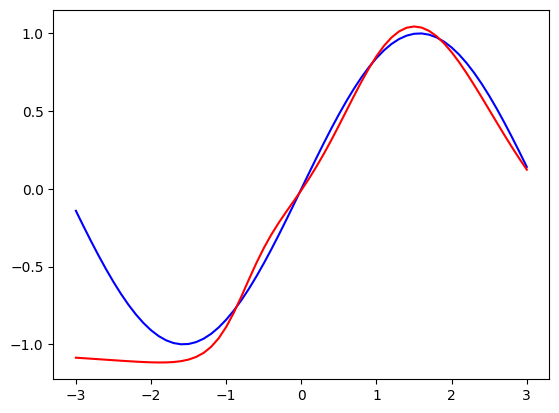

In [ ]:
plt.plot(X,Y,color='blue')
plt.plot(X, actual_Y,color='red')
plt.show()

**4B**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
def preprocess_data(x, y, limit):
        x = x.reshape(x.shape[0], 28 * 28, 1)
        x = x.astype("float32")/255

        y = to_categorical(y)
        y = y.reshape(y.shape[0], 10, 1)

        return x[:limit], y[:limit]

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, y_train = preprocess_data(x_train, y_train, 10000)
x_test, y_test = preprocess_data(x_test, y_test, 20)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
network = [
    Dense(784, 80),
    Sigmoid(),
    Dense(80, 10),
    Sigmoid()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(x_train,y_train):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(x)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=1.4511430197636288
2/(50, error=1.154174168258011
3/(50, error=1.072160748479313
4/(50, error=0.9902175601927653
5/(50, error=0.8795234004916708
6/(50, error=0.8476612577224033
7/(50, error=0.827709393819869
8/(50, error=0.8119962759282069
9/(50, error=0.7827820450983424
10/(50, error=0.7107924298654589
11/(50, error=0.6860030680604524
12/(50, error=0.6715364580953758
13/(50, error=0.6608283660672871
14/(50, error=0.6521803687356553
15/(50, error=0.6449313505936156
16/(50, error=0.6387562513939105
17/(50, error=0.6334247039802695
18/(50, error=0.6287473276023567
19/(50, error=0.6245761956675651
20/(50, error=0.6208000565187435
21/(50, error=0.6173367803155151
22/(50, error=0.6141292704691086
23/(50, error=0.6111420971846121
24/(50, error=0.6083480041557746
25/(50, error=0.6057142698281363
26/(50, error=0.6031926257820142
27/(50, error=0.6006743799211496
28/(50, error=0.5975258949101748
29/(50, error=0.5874397606559714
30/(50, error=0.5544556616821718
31/(50, error=0.525592

In [ ]:
def predict(network, input):
    output = input
    for layer in network:
        output = layer.forward(output)
    return output

In [ ]:
#!pip install simple-colors

In [ ]:
!pip install simple-colors
import simple_colors

In [ ]:
correct = 0

for x,y in zip(x_test, y_test):
    output = predict(network ,x)
    if np.argmax(output) == np.argmax(y):
        correct += 1
        print('pred:', np.argmax(output), '\ttrue:', np.argmax(y))
    else:
        print(simple_colors.red(f'pred: {np.argmax(output)} \ttrue: {np.argmax(y)}'))

accuracy = correct / len(y_test)
print(f"Accuracy: {accuracy}")
print(f"Correct: {correct}")

pred: 7 	true: 7
pred: 2 	true: 2
pred: 1 	true: 1
pred: 0 	true: 0
pred: 4 	true: 4
pred: 1 	true: 1
pred: 4 	true: 4
pred: 1 	true: 9
pred: 4 	true: 5
pred: 7 	true: 9
pred: 0 	true: 0
pred: 6 	true: 6
pred: 4 	true: 9
pred: 0 	true: 0
pred: 1 	true: 1
pred: 5 	true: 5
pred: 7 	true: 9
pred: 7 	true: 7
pred: 3 	true: 3
pred: 4 	true: 4
Accuracy: 0.75
Correct: 15


In [ ]:
error = errorlist
X = list(range(1,len(errorlist) + 1))

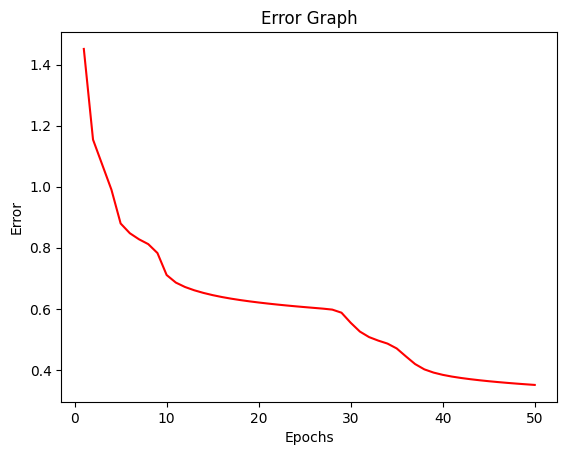

In [ ]:
plt.plot(X, error, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()